In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [4]:
data = pd.read_csv(r"python machine learning model xgboost - electricity demand dataset.csv")

In [5]:
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,31-Dec-24,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,31-Dec-24,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,31-Dec-24,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,31-Dec-24,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  object 
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [8]:
data["Timestamp"] = pd.to_datetime(data['Timestamp'])

C:\Users\rites\AppData\Local\Temp\ipykernel_22016\1773639543.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Timestamp"] = pd.to_datetime(data['Timestamp'])


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43848 non-null  datetime64[ns]
 1   hour         43837 non-null  float64       
 2   dayofweek    43839 non-null  float64       
 3   month        43840 non-null  float64       
 4   year         43843 non-null  float64       
 5   dayofyear    43843 non-null  float64       
 6   Temperature  43841 non-null  float64       
 7   Humidity     43838 non-null  float64       
 8   Demand       43841 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.0 MB


In [10]:
data = data.set_index('Timestamp')

In [11]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [12]:
data[['Temperature',	'Humidity',	'Demand']].describe()

,Temperature,Humidity,Demand
count,43841.000000,43838.000000,43841.000000
mean,25.067788,59.903007,5000.790976
std,12.821725,18.342604,1412.527409
min,3.000000,20.000000,1611.954020
25%,15.210186,46.241224,4015.668472
50%,25.003212,59.986720,5013.053367
75%,34.740971,73.796820,6000.803082
max,50.000000,95.000000,11910.705100


In [15]:
data.isnull().sum()

hour           11
dayofweek       9
month           8
year            5
dayofyear       5
Temperature     7
Humidity       10
Demand          7
dtype: int64

In [16]:
#to show the record that contain any null values

data[data.isna().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612


In [17]:
data[data.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
#drop those row that contain all null values
data = data.dropna(how='all')

In [19]:
data[data.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,


In [25]:
data[['hour','dayofweek','month','year','dayofyear']] = data[['hour','dayofweek','month','year','dayofyear']].ffill()

C:\Users\rites\AppData\Local\Temp\ipykernel_22016\409193883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['hour','dayofweek','month','year','dayofyear']] = data[['hour','dayofweek','month','year','dayofyear']].ffill()


In [30]:
data[['Temperature',	'Humidity']]=data[['Temperature',	'Humidity']].bfill()

C:\Users\rites\AppData\Local\Temp\ipykernel_22016\3557388791.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['Temperature',	'Humidity']]=data[['Temperature',	'Humidity']].bfill()


In [36]:
data['Demand'] = data['Demand'].interpolate(method='time')

C:\Users\rites\AppData\Local\Temp\ipykernel_22016\3652729601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Demand'] = data['Demand'].interpolate(method='time')


In [37]:
data.isnull().sum()

hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    0
Humidity       0
Demand         0
dtype: int64

In [38]:
#check quarter column in dataset
data.insert(5,'quarter',data.index.quarter)

In [39]:
data

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,4,3.000000,40.565916,4015.979957


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  float64
 1   dayofweek    43844 non-null  float64
 2   month        43844 non-null  float64
 3   year         43844 non-null  float64
 4   dayofyear    43844 non-null  float64
 5   quarter      43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 3.2 MB


In [45]:
#conveert the datatype from float to integer
data[['hour',	'dayofweek',	'month',	'year',	'dayofyear']]=data[['hour',	'dayofweek',	'month',	'year',	'dayofyear']].astype(int)

C:\Users\rites\AppData\Local\Temp\ipykernel_22016\1314361522.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['hour',	'dayofweek',	'month',	'year',	'dayofyear']]=data[['hour',	'dayofweek',	'month',	'year',	'dayofyear']].astype(int)


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  int64  
 1   dayofweek    43844 non-null  int64  
 2   month        43844 non-null  int64  
 3   year         43844 non-null  int64  
 4   dayofyear    43844 non-null  int64  
 5   quarter      43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(3), int32(1), int64(5)
memory usage: 3.2 MB


In [48]:
#create the week_of_year column in dataset
data.insert(5, 'weekofyear', data.index.isocalendar().week.astype(int))


In [49]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,3.000000,40.565916,4015.979957


In [50]:
#create a new column to check the weekend
data.insert(7,'is_weekend',data.index.dayofweek.isin([5,6]).astype(int))

In [51]:
data[data['is_weekend']==1]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-04,0,5,1,2020,4,1,1,1,3.000000,60.955363,2067.352696
2020-01-04,1,5,1,2020,4,1,1,1,3.000000,66.494073,2138.504702
2020-01-04,2,5,1,2020,4,1,1,1,3.000000,56.398199,1880.418696
2020-01-04,3,5,1,2020,4,1,1,1,4.474526,60.603500,2005.823854
2020-01-04,4,5,1,2020,4,1,1,1,7.738184,65.808825,2203.720413
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,19,6,12,2024,364,52,4,1,7.077721,46.341323,4304.049396
2024-12-29,20,6,12,2024,364,52,4,1,3.000000,69.641621,4146.583958
2024-12-29,21,6,12,2024,364,52,4,1,3.723222,46.751731,3366.641206


In [62]:
#import holiday package

import holidays

# Create holiday calendar for all years in the dataset
years = data.index.year.unique()
india_holidays = holidays.India(years=years)

# Safely compare using .date to match types and avoid warning
data.loc[:, 'Holiday'] = pd.Series(data.index.date).isin(india_holidays).astype(int).values



In [63]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Holiday
Timestamp,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,0
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,0
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,0
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,0
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,0
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,0
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,0


In [65]:
data['Holiday'].value_counts()


Holiday
0    41924
1     1920
Name: count, dtype: int64

In [70]:
data = data.drop('Holidays', axis=1, errors='ignore')


In [72]:
data = data.drop('Holiday', axis=1)


In [73]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957


In [74]:
#lages features - these are the past values of a time series data 


# use-past demand values are strong predictors they can be used as input to predict future values

In [76]:
# demand from the same hour yesterday, same hour last week
data['Demand_lag_24hr'] = data['Demand'].shift(24)

In [77]:
#24x7 = 168 hour for weekly shift
data['Demand_lag_168hr'] = data['Demand'].shift(168)

In [78]:
data.iloc[160 : 200]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-07,16,1,1,2020,7,2,1,0,14.016616,37.637752,4587.785143,4733.816549,NaN
2020-01-07,17,1,1,2020,7,2,1,0,6.736632,54.734906,4833.704288,4796.039663,NaN
2020-01-07,18,1,1,2020,7,2,1,0,17.782435,49.297649,5400.257796,4791.518998,NaN
2020-01-07,19,1,1,2020,7,2,1,0,3.000000,37.696671,4424.534926,4492.165854,NaN
2020-01-07,20,1,1,2020,7,2,1,0,7.116704,46.152197,4279.454320,4398.302015,NaN
2020-01-07,21,1,1,2020,7,2,1,0,5.158936,44.385460,3768.807077,3705.698515,NaN
2020-01-07,22,1,1,2020,7,2,1,0,3.000000,46.821530,2924.189540,3211.918549,NaN
2020-01-07,23,1,1,2020,7,2,1,0,3.000000,44.708096,2657.653050,2857.968639,NaN
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872


In [81]:
#rolling mean & standard Deviation

data['Demand_rolling_mean_24hr']=data['Demand'].rolling(window=24).mean()

In [82]:
data['Demand_rolling_std_24hr']=data['Demand'].rolling(window=24).std()

In [86]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


In [88]:
#drop all row having null values 
data = data.dropna()

In [89]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


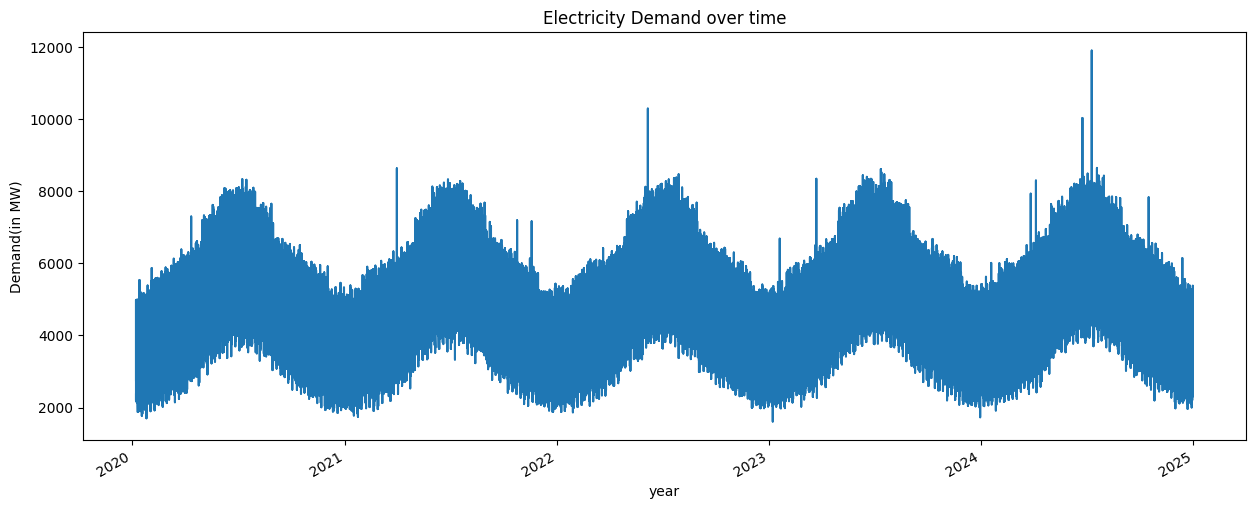

In [92]:
# plot raw demand over time
data['Demand'].plot(figsize = (15,6), title = "Electricity Demand over time")
plt.xlabel("year")
plt.ylabel("Demand(in MW)")
plt.show()

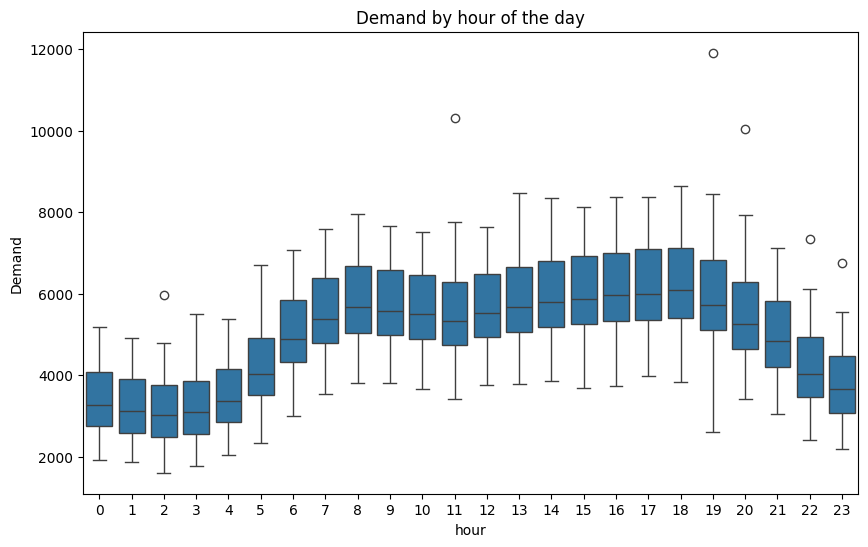

In [93]:
# visualise Demand by hour of day 
plt.figure(figsize = (10,6))
sns.boxplot(data = data, x= 'hour', y = 'Demand')
plt.title('Demand by hour of the day')
plt.show()

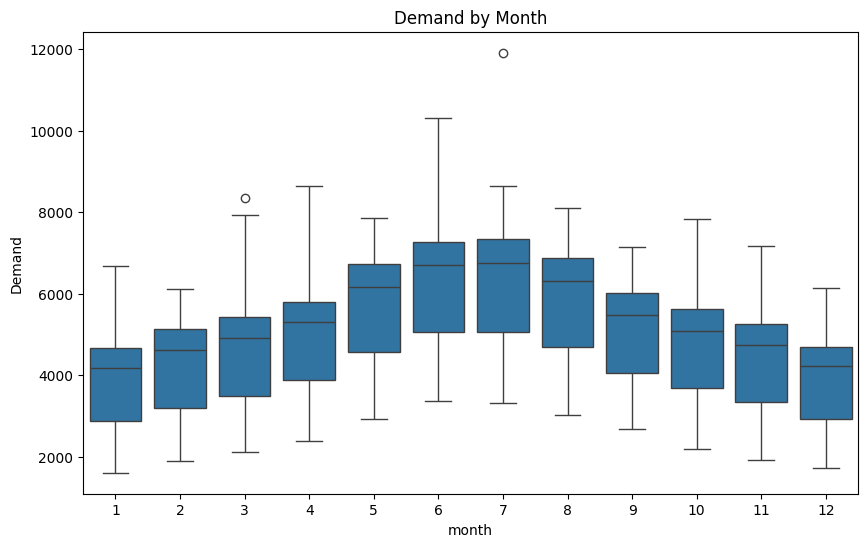

In [96]:
# visualize Demand by month

plt.figure(figsize= (10,6))
sns.boxplot(data=data,x='month', y='Demand')
plt.title('Demand by Month')
plt.show()

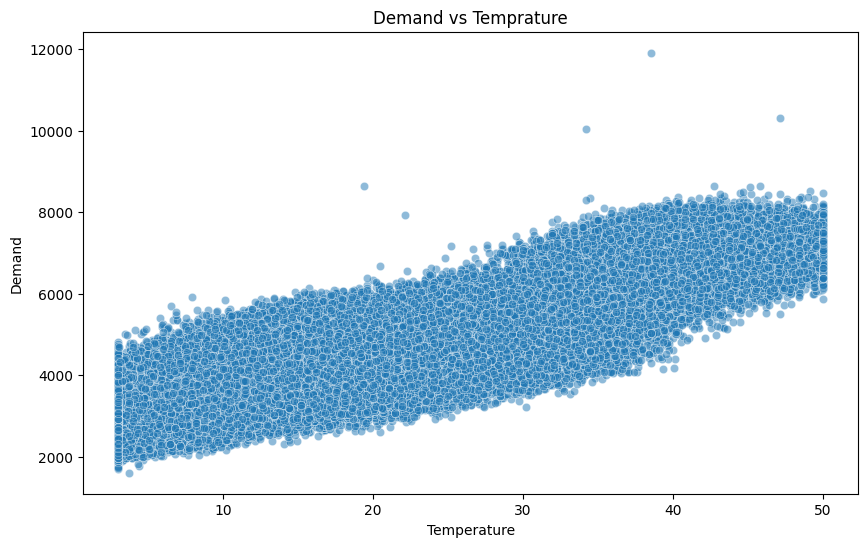

In [99]:
#scatterplot of Demand VS Temprature

plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Temperature',y='Demand',alpha=0.5)
plt.title("Demand vs Temprature")
plt.show()


In [101]:
#correlation maatrix
data.corr()

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
hour,1.000000,-0.000115,0.000180,0.000102,0.000171,0.000178,0.000184,-0.000209,0.051951,-0.293458,0.396108,0.396089,0.396626,0.000259,0.006966
dayofweek,-0.000115,1.000000,0.001075,-0.001110,0.001074,0.000205,0.002582,0.790556,-0.000997,-0.002241,-0.127262,-0.000123,-0.127109,-0.096550,-0.039042
month,0.000180,0.001075,1.000000,-0.008866,0.996483,0.971869,0.971288,-0.001224,-0.014012,0.597453,0.030458,0.038615,0.085715,0.055706,-0.009372
year,0.000102,-0.001110,-0.008866,1.000000,-0.009407,-0.020163,-0.007481,0.000965,-0.005114,-0.000723,0.046514,0.046286,0.046426,0.074826,-0.000505
dayofyear,0.000171,0.001074,0.996483,-0.009407,1.000000,0.973509,0.968174,-0.001039,-0.016933,0.596751,0.028252,0.036424,0.083656,0.052175,-0.012346
weekofyear,0.000178,0.000205,0.971869,-0.020163,0.973509,1.000000,0.947413,0.000236,-0.025676,0.596420,0.021414,0.028866,0.076468,0.040598,-0.023263
quarter,0.000184,0.002582,0.971288,-0.007481,0.968174,0.947413,1.000000,0.001131,-0.011304,0.614172,0.033047,0.041335,0.087875,0.059987,-0.004336
is_weekend,-0.000209,0.790556,-0.001224,0.000965,-0.001039,0.000236,0.001131,1.000000,-0.001066,-0.001308,-0.160294,-0.047904,-0.160147,-0.162620,-0.144474
Temperature,0.051951,-0.000997,-0.014012,-0.005114,-0.016933,-0.025676,-0.011304,-0.001066,1.000000,0.001396,0.828245,0.804343,0.796094,0.772259,0.568798
Humidity,-0.293458,-0.002241,0.597453,-0.000723,0.596751,0.596420,0.614172,-0.001308,0.001396,1.000000,-0.066243,-0.077808,-0.031584,0.069116,0.002232


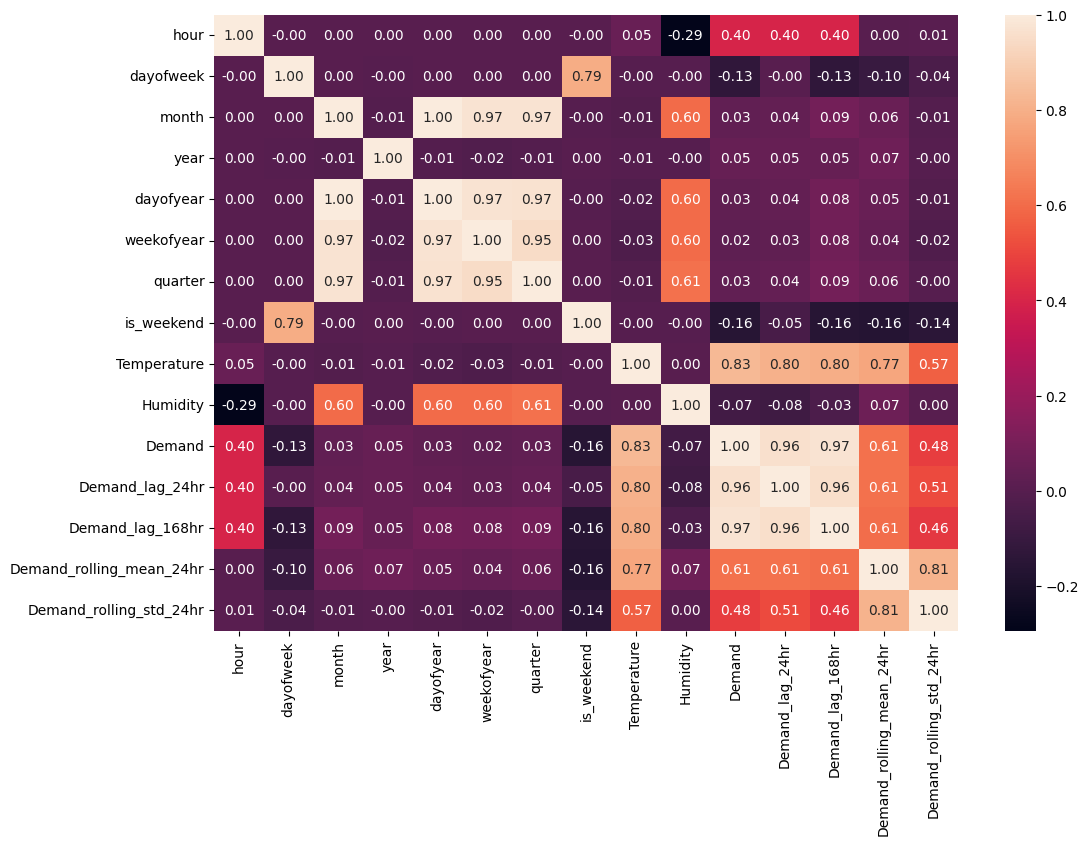

In [102]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(),annot=True,fmt=".2f")
plt.show()


In [103]:
#defining target variable(Y)

Y = data.Demand #targetvariable or dependent variable


In [104]:
#defining fetures(X)
X = data.drop('Demand',axis=1) #independent variable or fetures or predictors

In [105]:
#splitting the data into training and testing

In [118]:
X_train = X.loc[ : '2023-12-31']   #taking 80% data as training data

In [119]:
Y_train = Y.loc[ :'2023-12-31']   

In [120]:
X_train

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31,19,6,12,2023,365,52,4,1,6.721774,46.627264,3894.908251,3840.654680,3597.790591,879.089476
2023-12-31,20,6,12,2023,365,52,4,1,7.557696,58.505012,3797.287793,4122.218903,3599.126925,879.430235
2023-12-31,21,6,12,2023,365,52,4,1,3.000000,48.001079,3280.602315,3307.887152,3604.785551,877.726873


In [121]:
Y_train

Timestamp
2020-01-08    2363.060115
2020-01-08    2282.558766
2020-01-08    2193.324174
2020-01-08    2208.724679
2020-01-08    2402.611018
                 ...     
2023-12-31    4185.721624
2023-12-31    3829.359810
2023-12-31    3416.409325
2023-12-31    3188.143951
2023-12-31    2631.860751
Name: Demand, Length: 34892, dtype: float64

In [122]:
X_test = X.loc['2024-01-01' : ]

In [123]:
Y_test = Y.loc['2024-01-01' : ]

In [124]:
X_test

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,Demand_lag_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2024-01-01,0,0,1,2024,1,1,1,0,3.000000,65.297046,2373.967493,2752.003113,3626.185642,856.204515
2024-01-01,1,0,1,2024,1,1,1,0,3.000000,69.068654,2328.972904,2419.747602,3640.380403,836.357296
2024-01-01,2,0,1,2024,1,1,1,0,3.000000,80.885372,1729.176090,2292.834087,3669.813854,776.458065
2024-01-01,3,0,1,2024,1,1,1,0,7.788675,66.501527,2257.337352,2507.704476,3685.801618,749.595470
2024-01-01,4,0,1,2024,1,1,1,0,6.607828,57.858109,2516.948873,2690.933257,3692.926651,738.736316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,3859.260701,3856.359014,4052.475170,977.565114


In [125]:
Y_test

Timestamp
2024-01-01    2720.606072
2024-01-01    2669.647167
2024-01-01    2435.578924
2024-01-01    2641.043699
2024-01-01    2687.949643
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 8784, dtype: float64

In [126]:
print(X_train.shape)
print(Y_train.shape)

(34892, 14)
(34892,)


In [127]:
print(X_test.shape)
print(Y_test.shape)

(8784, 14)
(8784,)


XGBoost 

xgboost is a powerfull algorithm for time series forcasting as it can handle non-linear data easily, it can handle seasonality and trends in time-series effectively

In [132]:
!pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
from xgboost import XGBRegressor #from xgboost library we are importing XGBRegressor class 

In [137]:
from sklearn.metrics import mean_absolute_error,mean_squared_error #from sklearn library importing two fundamental metrics to evaluate the performance of the model

In [138]:
#from model selection module of scikit learn's library import Timeseries split class
from sklearn.model_selection import TimeSeriesSplit
#Time series split class performs appropriate cross-validation when dealing with time series data

In [152]:
# initialize and train the model
model_xgb = XGBRegressor(n_estimetors = 1000,
                         early_stopping_rounds = 50,
                         learning_rate = 0.2,
                         random_state = 42,
                         objective = 'reg:squarederror')
                         

In [153]:
model_xgb.fit(X_train,Y_train,eval_set=[(X_train,Y_train),(X_test,Y_test)],verbose=False)

C:\Users\rites\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\callback.py:386: UserWarning: [22:40:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "n_estimetors" } are not used.

  self.starting_round = model.num_boosted_rounds()


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_estimetors=1000, n_jobs=None, ...)

In [154]:
#make prediction
predictions_xgb=model_xgb.predict(X_test)

In [155]:
#evaluating the model
rmse_xgb = np.sqrt(mean_squared_error(Y_test,predictions_xgb)) 

In [156]:
mae_xgb = mean_absolute_error(Y_test,predictions_xgb)

In [157]:
print('XGBoost RMSE:',rmse_xgb)
print("XGBoost MAE:",mae_xgb)

XGBoost RMSE: 164.88698136440587
XGBoost MAE: 114.19434882839272


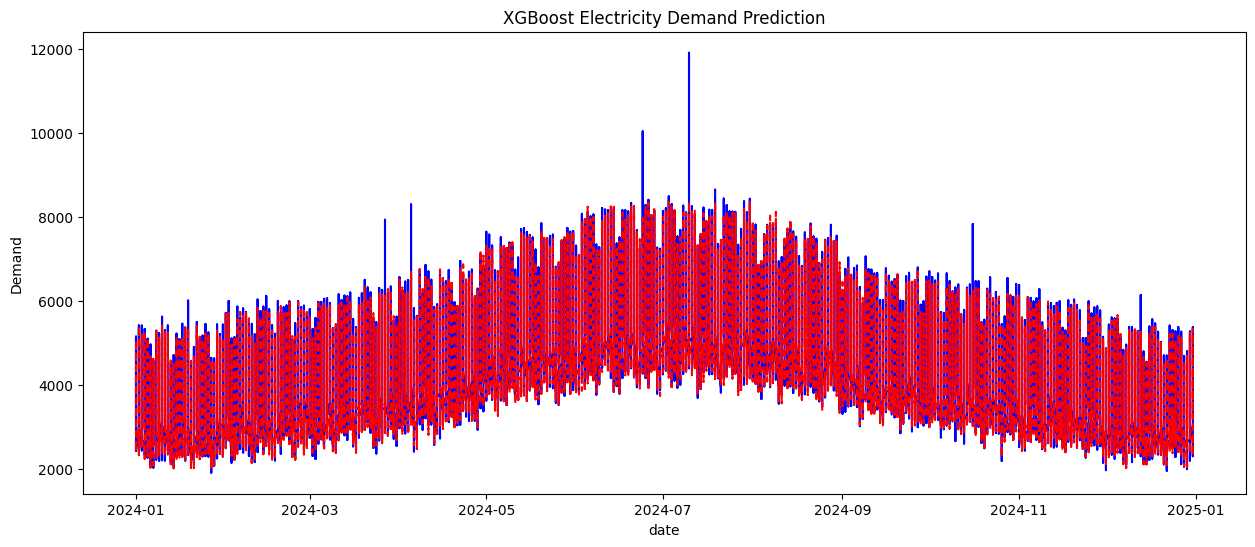

In [158]:
#visualise the predictions
plt.figure(figsize=(15,6))
plt.plot(Y_test.index,Y_test,label= 'Actual Demand', color = 'Blue')
plt.plot(Y_test.index, predictions_xgb, label= 'Predicted Demand',color ='Red', linestyle = '--')

plt.title('XGBoost Electricity Demand Prediction')
plt.xlabel('date')
plt.ylabel('Demand')
plt.show()


In [159]:
#save the model
import joblib
joblib.dump(model_xgb,'Electricity_xgb_prediction_model.pkl')

['Electricity_xgb_prediction_model.pkl']